# Re-ranking Hyperparameter Comparison Notebook

This notebook extends the simple setup from retrieval_query_strategy_2_helper_func.ipynb to compare **3 reranking configurations** under a fixed retrieval setup.

Flow:
1. Build query text (variant 1 style).
2. Retrieve top-N candidates from Qdrant.
3. Apply 3 explainable reranking parameter sets.
4. Compare Recall@K, Precision@K, and MRR@K across parameter sets.
5. Identify the best set using metric-wise and composite summaries.

In [1]:
import ast
import json
import random
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer

RANDOM_SEED = 42
SAMPLE_SIZE = 50
TOP_K_FINAL = 7
TOP_N_CANDIDATES = 25
COLLECTION_NAME = "guideline_embeddings"
MODEL_NAME = "BAAI/bge-large-en-v1.5"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EVAL_PATH = DATA_DIR / "evaluation.json"

GROUPED_VIOLATION_CATEGORIES = [
    "naming_convention",
    "unused_import",
    "indentation",
    "mutable_default",
    "documentation_formatting",
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation file: {EVAL_PATH}")

Project root: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project
Evaluation file: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation.json


In [2]:
import importlib
import sys

sys.path.insert(0, str(PROJECT_ROOT / "src"))
qs = importlib.import_module("rag_model.query_strategy")
qs = importlib.reload(qs)

# Use the refined regex variant when available; fallback to v1.
query_builder = getattr(qs, "query_strategy_regex_intelligent_v2", qs.query_strategy_regex_intelligent)
retrieve_guidelines = qs.retrieve_guidelines

print("Loaded query_strategy module.")
print(f"Active query builder: {query_builder.__name__}")

Loaded query_strategy module.
Active query builder: query_strategy_regex_intelligent_v2


In [3]:
with EVAL_PATH.open("r", encoding="utf-8") as f:
    evaluation_data = json.load(f)

random.seed(RANDOM_SEED)
sampled_entries = random.sample(evaluation_data, k=min(SAMPLE_SIZE, len(evaluation_data)))
gt_map = {e.get("id"): e.get("ground_truth_reviews") for e in evaluation_data}

client = QdrantClient(url="http://localhost:6333")
model = SentenceTransformer(MODEL_NAME)

print(f"Sampled entries: {len(sampled_entries)}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sampled entries: 50


In [4]:
# Re-ranking parameter sets for comparison
RERANK_CONFIGS = [
    {
        "name": "balanced",
        "LEXICAL_WEIGHT": 0.35,
        "CATEGORY_BONUS": 0.15,
        "RANK_PENALTY": 0.01,
        "MAX_PER_CATEGORY": 2,
        "description": "Default: balanced semantic + lexical signal with mild diversity control",
    },
    {
        "name": "semantic_lean",
        "LEXICAL_WEIGHT": 0.20,
        "CATEGORY_BONUS": 0.10,
        "RANK_PENALTY": 0.005,
        "MAX_PER_CATEGORY": 3,
        "description": "Semantic-focused: weaker lexical/category boosts, lower rank penalty, allows more repeats",
    },
    {
        "name": "diversity_lexical",
        "LEXICAL_WEIGHT": 0.50,
        "CATEGORY_BONUS": 0.25,
        "RANK_PENALTY": 0.02,
        "MAX_PER_CATEGORY": 1,
        "description": "Diversity-focused: stronger lexical/category boosts, stronger rank penalty, strict per-category cap",
    },
]

config_df = pd.DataFrame(RERANK_CONFIGS)
display(config_df[["name", "LEXICAL_WEIGHT", "CATEGORY_BONUS", "RANK_PENALTY", "MAX_PER_CATEGORY", "description"]])

pr_rows = []
config_names = [cfg["name"] for cfg in RERANK_CONFIGS]

for entry in sampled_entries:
    query_text = query_builder(entry)
    points = retrieve_guidelines(
        query_text=query_text,
        repo_name=entry.get("repo"),
        top_k=TOP_N_CANDIDATES,
        client=client,
        embed_model=model,
        collection_name=COLLECTION_NAME,
    )

    candidate_rows = []
    query_tokens = set(str(query_text).lower().replace("_", " ").split())
    query_text_lc = str(query_text).lower()

    for rank_idx, point in enumerate(points):
        payload = getattr(point, "payload", None)
        obj = payload if isinstance(payload, dict) else None
        if obj is None and isinstance(payload, str):
            try:
                maybe = ast.literal_eval(payload)
                if isinstance(maybe, dict):
                    obj = maybe
            except Exception:
                obj = None

        category = None
        text_val = ""
        if isinstance(obj, dict):
            for key in ["violation_category", "category", "label", "violation"]:
                val = obj.get(key)
                if isinstance(val, str) and val.strip():
                    category = val.strip().lower().replace("-", "_").replace(" ", "_")
                    break
            for key in ["text", "content", "chunk", "guideline"]:
                val = obj.get(key)
                if isinstance(val, str) and val.strip():
                    text_val = val
                    break

        if not text_val and isinstance(payload, str):
            text_val = payload

        sem_score = float(getattr(point, "score", 0.0) or 0.0)
        chunk_tokens = set(str(text_val).lower().replace("_", " ").split())
        lexical_overlap = len(query_tokens & chunk_tokens) / max(1, len(query_tokens))
        is_category_match = int(bool(category and category in query_text_lc))

        candidate_rows.append({
            "rank_idx": rank_idx,
            "category": category,
            "sem_score": sem_score,
            "lexical_overlap": lexical_overlap,
            "is_category_match": is_category_match,
        })

    cand_df = pd.DataFrame(candidate_rows)

    # Baseline: original retrieval order (kept as reference only)
    baseline_categories = [
        c for c in cand_df.sort_values("rank_idx")["category"].tolist()[:TOP_K_FINAL] if c
    ]

    reranked_by_config = {}
    for cfg in RERANK_CONFIGS:
        scored_df = cand_df.copy()
        scored_df["rerank_score"] = (
            scored_df["sem_score"]
            + (cfg["LEXICAL_WEIGHT"] * scored_df["lexical_overlap"])
            + (cfg["CATEGORY_BONUS"] * scored_df["is_category_match"])
            - (cfg["RANK_PENALTY"] * scored_df["rank_idx"])
        )

        reranked_categories = []
        cat_counts = {}
        for c in scored_df.sort_values("rerank_score", ascending=False)["category"].tolist():
            if not c:
                continue
            prev = cat_counts.get(c, 0)
            if prev >= cfg["MAX_PER_CATEGORY"]:
                continue
            reranked_categories.append(c)
            cat_counts[c] = prev + 1
            if len(reranked_categories) >= TOP_K_FINAL:
                break

        reranked_by_config[cfg["name"]] = reranked_categories

    gt_categories = []
    for gt in (gt_map.get(entry.get("id")) or []):
        cat = gt.get("violation_category") if isinstance(gt, dict) else gt
        if isinstance(cat, str):
            cat_norm = cat.strip().lower().replace("-", "_").replace(" ", "_")
            if cat_norm in GROUPED_VIOLATION_CATEGORIES:
                gt_categories.append(cat_norm)

    row_obj = {
        "id": entry.get("id"),
        "repo": entry.get("repo"),
        "query_text": query_text,
        "gt_categories": sorted(set(gt_categories)),
        "baseline_categories": baseline_categories,
    }
    for cfg_name in config_names:
        row_obj[f"reranked_{cfg_name}"] = reranked_by_config[cfg_name]

    pr_rows.append(row_obj)

pr_df = pd.DataFrame(pr_rows)
display_cols = ["id", "repo", "gt_categories", "baseline_categories"] + [f"reranked_{n}" for n in config_names]
display(pr_df[display_cols].head(10))

,name,LEXICAL_WEIGHT,CATEGORY_BONUS,RANK_PENALTY,MAX_PER_CATEGORY,description
0,balanced,0.35,0.15,0.010,2,Default: balanced semantic + lexical signal wi...
1,semantic_lean,0.20,0.10,0.005,3,Semantic-focused: weaker lexical/category boos...
2,diversity_lexical,0.50,0.25,0.020,1,Diversity-focused: stronger lexical/category b...


,id,repo,gt_categories,baseline_categories,reranked_balanced,reranked_semantic_lean,reranked_diversity_lexical
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,"[mutable_default, naming_convention, unused_im...","[mutable_default, mutable_default, naming_conv...","[mutable_default, mutable_default, naming_conv...","[mutable_default, mutable_default, naming_conv...","[mutable_default, naming_convention, unused_im..."
1,synthetic-django_PR_36,kannan-dedsec/synthetic-django,[naming_convention],"[indentation, unused_import, naming_convention...","[indentation, unused_import, indentation, nami...","[indentation, unused_import, indentation, nami...","[indentation, unused_import, naming_convention..."
2,synthetic-django_PR_24,kannan-dedsec/synthetic-django,"[mutable_default, naming_convention]","[naming_convention, naming_convention, mutable...","[naming_convention, naming_convention, mutable...","[naming_convention, naming_convention, mutable...","[naming_convention, mutable_default, documenta..."
3,synthetic-fastapi_PR_38,kannan-dedsec/synthetic-fastapi,[unused_import],"[unused_import, unused_import, unused_import, ...","[unused_import, unused_import, documentation_f...","[unused_import, unused_import, unused_import, ...","[unused_import, documentation_formatting, nami..."
4,synthetic-fastapi_PR_34,kannan-dedsec/synthetic-fastapi,[naming_convention],"[naming_convention, naming_convention, naming_...","[naming_convention, naming_convention, unused_...","[naming_convention, naming_convention, naming_...","[naming_convention, unused_import, documentati..."
5,synthetic-fastapi_PR_31,kannan-dedsec/synthetic-fastapi,[unused_import],"[naming_convention, unused_import, naming_conv...","[naming_convention, unused_import, naming_conv...","[naming_convention, unused_import, naming_conv...","[naming_convention, unused_import, documentati..."
6,synthetic-django_PR_39,kannan-dedsec/synthetic-django,"[documentation_formatting, indentation, naming...","[naming_convention, indentation, naming_conven...","[indentation, naming_convention, naming_conven...","[indentation, naming_convention, naming_conven...","[indentation, naming_convention, unused_import..."
7,synthetic-django_PR_35,kannan-dedsec/synthetic-django,"[documentation_formatting, unused_import]","[unused_import, naming_convention, naming_conv...","[unused_import, naming_convention, naming_conv...","[unused_import, naming_convention, naming_conv...","[unused_import, naming_convention, indentation..."
8,synthetic-sklearn_PR_30,kannan-dedsec/synthetic-sklearn,"[mutable_default, naming_convention]","[mutable_default, naming_convention, mutable_d...","[mutable_default, mutable_default, naming_conv...","[mutable_default, mutable_default, naming_conv...","[mutable_default, naming_convention, unused_im..."
9,synthetic-pandas_PR_32,kannan-dedsec/synthetic-pandas,[naming_convention],"[documentation_formatting, indentation, naming...","[documentation_formatting, naming_convention, ...","[documentation_formatting, naming_convention, ...","[documentation_formatting, naming_convention, ..."


In [16]:
k_values = [1, 3, 5, 7]
records = []
category_records = []

# Include baseline (no reranking) alongside reranked configurations.
eval_systems = [{"name": "baseline", "col": "baseline_categories", "kind": "baseline"}] + [
    {"name": cfg["name"], "col": f"reranked_{cfg['name']}", "kind": "reranked"}
    for cfg in RERANK_CONFIGS
]

for system in eval_systems:
    cfg_name = system["name"]
    col_name = system["col"]

    for k in k_values:
        for _, row in pr_df.iterrows():
            gt_set = set(row["gt_categories"] or [])
            topk = [c for c in (row[col_name] or [])[:k] if c]

            if len(gt_set) == 0:
                continue

            matched = {c for c in gt_set if c in topk}
            recall = len(matched) / min(5, len(gt_set))
            precision = (sum(1 for c in topk if c in gt_set) / len(topk)) if topk else 0.0

            rr_vals = []
            for g in gt_set:
                rr = 0.0
                for rank, c in enumerate(topk, start=1):
                    if c == g:
                        rr = 1.0 / rank
                        break
                rr_vals.append(rr)
            mrr = sum(rr_vals) / len(rr_vals) if rr_vals else 0.0

            records.append({
                "config": cfg_name,
                "k": k,
                "id": row["id"],
                "recall_at_k": recall,
                "precision_at_k": precision,
                "mrr_at_k": mrr,
            })

        for cat in GROUPED_VIOLATION_CATEGORIES:
            gt_count = 0
            ret_count = 0
            tp = 0
            for _, row in pr_df.iterrows():
                gt_set = set(row["gt_categories"] or [])
                topk = [c for c in (row[col_name] or [])[:k] if c]
                if cat in gt_set:
                    gt_count += 1
                if cat in topk:
                    ret_count += 1
                if cat in gt_set and cat in topk:
                    tp += 1

            fp = ret_count - tp
            category_records.append({
                "config": cfg_name,
                "k": k,
                "category": cat,
                "gt_count": gt_count,
                "retrieved_count": ret_count,
                "tp": tp,
                "fp": fp,
                "recall": (tp / gt_count) if gt_count else 0.0,
                "precision": (tp / ret_count) if ret_count else 0.0,
            })

metrics_long_df = pd.DataFrame(records)
overall_df = metrics_long_df.groupby(["config", "k"], as_index=False)[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean()
category_df = pd.DataFrame(category_records)

# Aggregate across K for a single summary score per configuration/system.
summary_df = overall_df.groupby("config", as_index=False)[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean()
summary_df["composite_score"] = summary_df[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean(axis=1)
summary_df = summary_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

# Keep reranking model-selection separate from baseline comparison.
rerank_summary_df = summary_df[summary_df["config"] != "baseline"].copy()
best_config = rerank_summary_df.loc[0, "config"] if not rerank_summary_df.empty else None

print("Overall metrics by system and K (includes baseline):")
display(overall_df)
print("Average metrics across K (with composite score):")
display(summary_df)
print("Average metrics across K (reranked configs only):")
display(rerank_summary_df)
print(f"Best reranked configuration by composite score: {best_config}")
print("Category-level stats (includes baseline):")
display(category_df.head(40))

Overall metrics by system and K (includes baseline):


,config,k,recall_at_k,precision_at_k,mrr_at_k
0,balanced,1,0.481667,0.780000,0.481667
1,balanced,3,0.770000,0.700000,0.602222
2,balanced,5,0.921667,0.604000,0.636389
3,balanced,7,0.986667,0.516952,0.646627
4,baseline,1,0.501667,0.800000,0.501667
5,baseline,3,0.703333,0.746667,0.586667
6,baseline,5,0.811667,0.732000,0.610417
7,baseline,7,0.823333,0.702857,0.612083
8,diversity_lexical,1,0.481667,0.780000,0.481667
9,diversity_lexical,3,0.921667,0.560000,0.676389


Average metrics across K (with composite score):


,config,recall_at_k,precision_at_k,mrr_at_k,composite_score
0,diversity_lexical,0.847500,0.576333,0.636500,0.686778
1,baseline,0.710000,0.745381,0.577708,0.677696
2,semantic_lean,0.744167,0.714095,0.574677,0.677646
3,balanced,0.790000,0.650238,0.591726,0.677321


Average metrics across K (reranked configs only):


,config,recall_at_k,precision_at_k,mrr_at_k,composite_score
0,diversity_lexical,0.847500,0.576333,0.636500,0.686778
2,semantic_lean,0.744167,0.714095,0.574677,0.677646
3,balanced,0.790000,0.650238,0.591726,0.677321


Best reranked configuration by composite score: diversity_lexical
Category-level stats (includes baseline):


,config,k,category,gt_count,retrieved_count,tp,fp,recall,precision
0,baseline,1,naming_convention,24,21,15,6,0.625000,0.714286
1,baseline,1,unused_import,33,15,14,1,0.424242,0.933333
2,baseline,1,indentation,12,2,1,1,0.083333,0.500000
3,baseline,1,mutable_default,13,9,9,0,0.692308,1.000000
4,baseline,1,documentation_formatting,12,3,1,2,0.083333,0.333333
5,baseline,3,naming_convention,24,34,21,13,0.875000,0.617647
6,baseline,3,unused_import,33,27,20,7,0.606061,0.740741
7,baseline,3,indentation,12,7,4,3,0.333333,0.571429
8,baseline,3,mutable_default,13,12,12,0,0.923077,1.000000
9,baseline,3,documentation_formatting,12,6,1,5,0.083333,0.166667


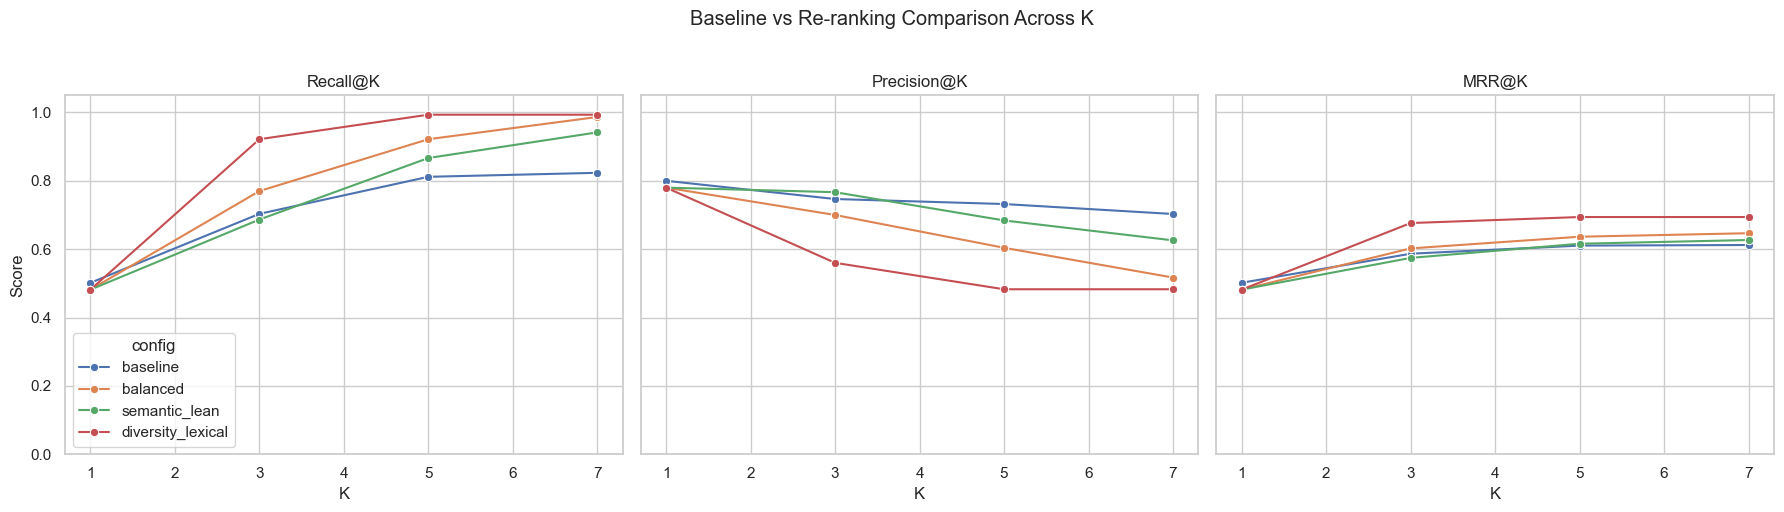

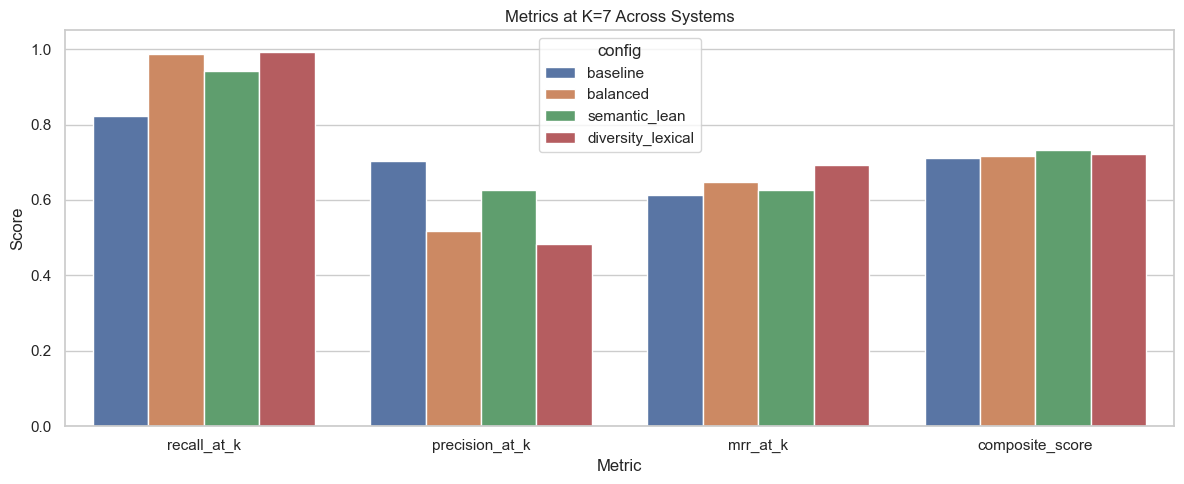

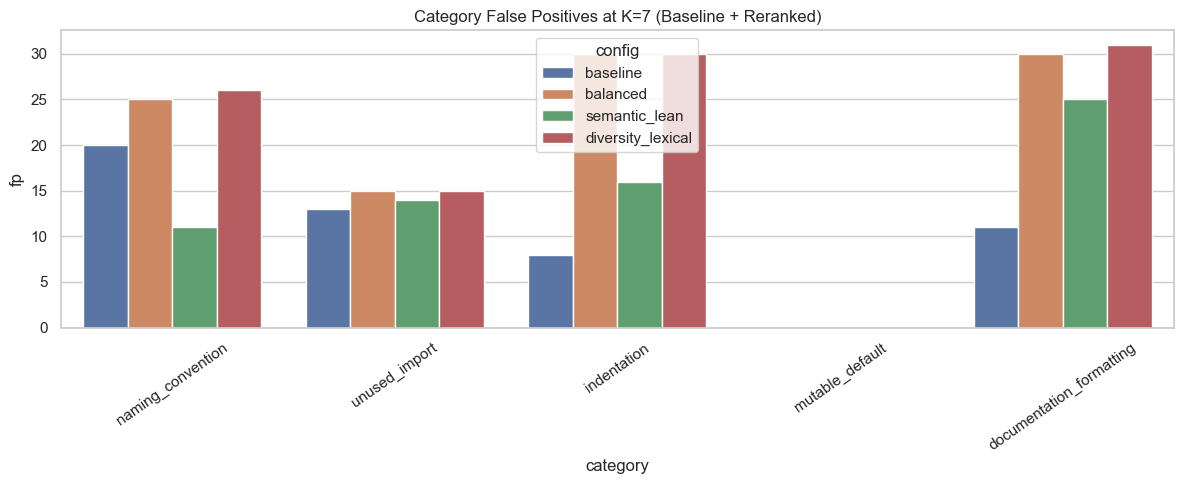

In [23]:
sns.set_theme(style="whitegrid")
PLOT_EXPORTS = {}

# Fixed legend order + color mapping across all plots.
system_order = ["baseline", "balanced", "semantic_lean", "diversity_lexical"]
system_palette = {
    "baseline": "#4C72B0",
    "balanced": "#DD8452",
    "semantic_lean": "#55A868",
    "diversity_lexical": "#C44E52",
}
present_configs = set(overall_df["config"].unique())
plot_hue_order = [name for name in system_order if name in present_configs]

# 1) Metric-vs-K curves for baseline + each reranked config
fig1, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
metric_cols = ["recall_at_k", "precision_at_k", "mrr_at_k"]
metric_titles = ["Recall@K", "Precision@K", "MRR@K"]

for ax, metric_col, metric_title in zip(axes, metric_cols, metric_titles):
    sns.lineplot(
        data=overall_df,
        x="k",
        y=metric_col,
        hue="config",
        hue_order=plot_hue_order,
        palette=system_palette,
        marker="o",
        ax=ax,
    )
    ax.set_title(metric_title)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("K")
    ax.set_ylabel("Score")

# Keep only one legend to reduce clutter
for i in [1, 2]:
    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

plt.suptitle("Baseline vs Re-ranking Comparison Across K", y=1.02)
plt.tight_layout()
PLOT_EXPORTS["metrics_vs_k"] = fig1
plt.show()

# 2) Average metric bars by system/config — now only at TOP_K_FINAL
# Filter overall_df to only the final K before melting
k_df = overall_df[overall_df["k"] == TOP_K_FINAL].copy()
# compute composite score for that K only
k_df["composite_score"] = k_df[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean(axis=1)
summary_plot_df = k_df.melt(
    id_vars=["config"],
    value_vars=["recall_at_k", "precision_at_k", "mrr_at_k", "composite_score"],
    var_name="metric",
    value_name="value",
)

fig2 = plt.figure(figsize=(12, 5))
sns.barplot(
    data=summary_plot_df,
    x="metric",
    y="value",
    hue="config",
    hue_order=plot_hue_order,
    palette=system_palette,
    )
plt.ylim(0, 1.05)
plt.title(f"Metrics at K={TOP_K_FINAL} Across Systems")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
PLOT_EXPORTS["average_metrics_by_config"] = fig2
plt.show()

# 3) Category-level false positives at K=7 for stability checks
k_show = TOP_K_FINAL
cat_plot = category_df[category_df["k"] == k_show].copy()

fig3 = plt.figure(figsize=(12, 5))
sns.barplot(
    data=cat_plot,
    x="category",
    y="fp",
    hue="config",
    hue_order=plot_hue_order,
    palette=system_palette,
    )
plt.title(f"Category False Positives at K={k_show} (Baseline + Reranked)")
plt.xticks(rotation=35)
plt.tight_layout()
PLOT_EXPORTS["category_false_positives_k7"] = fig3
plt.show()

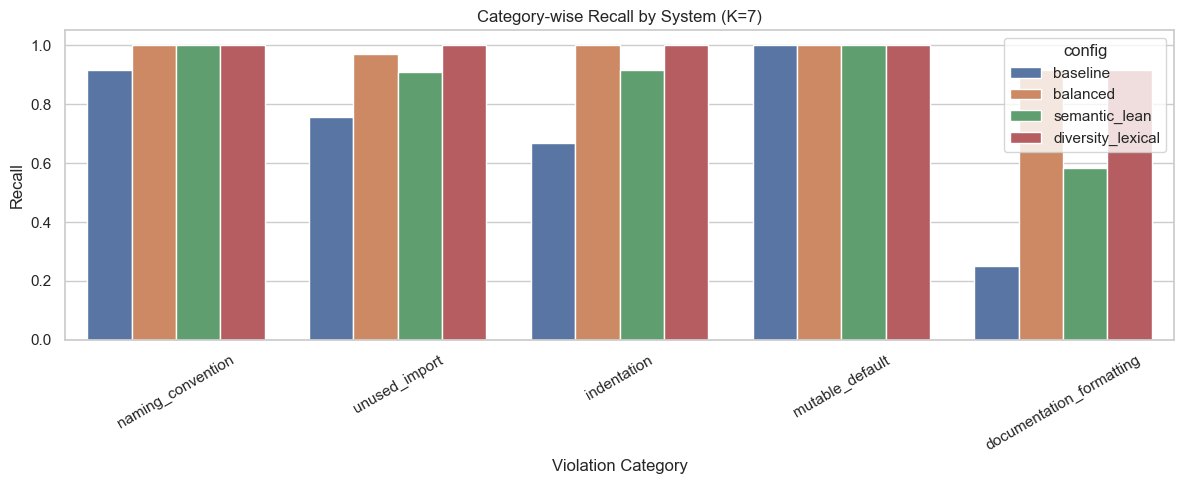

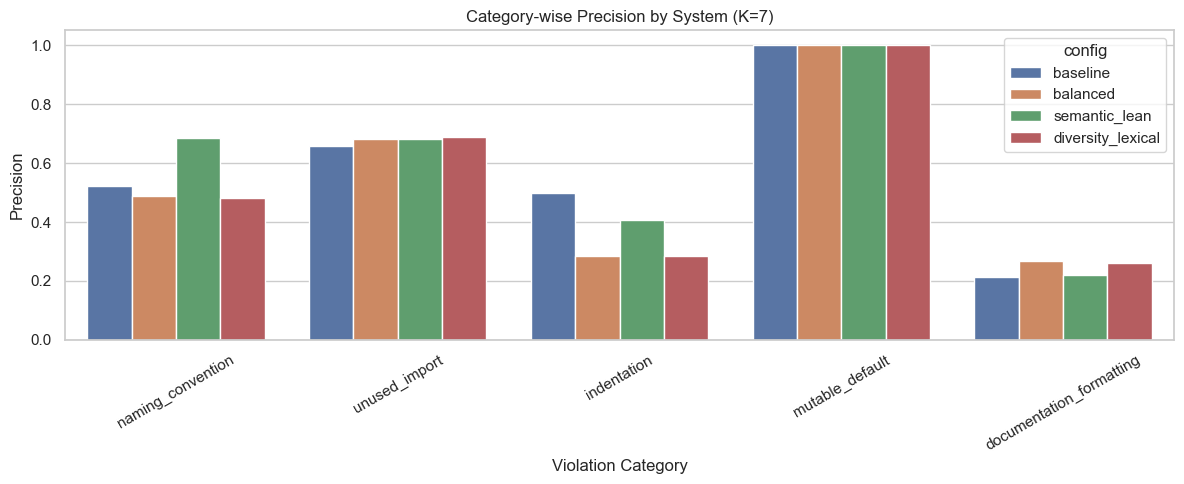

,config,category,recall,precision,tp,fp,gt_count,retrieved_count
0,balanced,naming_convention,1.000000,0.489796,24,25,24,49
1,baseline,naming_convention,0.916667,0.523810,22,20,24,42
2,diversity_lexical,naming_convention,1.000000,0.480000,24,26,24,50
3,semantic_lean,naming_convention,1.000000,0.685714,24,11,24,35
4,balanced,unused_import,0.969697,0.680851,32,15,33,47
5,baseline,unused_import,0.757576,0.657895,25,13,33,38
6,diversity_lexical,unused_import,1.000000,0.687500,33,15,33,48
7,semantic_lean,unused_import,0.909091,0.681818,30,14,33,44
8,balanced,indentation,1.000000,0.285714,12,30,12,42
9,baseline,indentation,0.666667,0.500000,8,8,12,16


In [21]:
# Category-wise Recall and Precision comparison at final K (includes baseline)
k_eval = TOP_K_FINAL
cat_metrics_plot = category_df[category_df["k"] == k_eval].copy()

# Keep category order consistent with project category list
cat_metrics_plot["category"] = pd.Categorical(
    cat_metrics_plot["category"],
    categories=GROUPED_VIOLATION_CATEGORIES,
    ordered=True,
)
cat_metrics_plot = cat_metrics_plot.sort_values(["category", "config"]).reset_index(drop=True)

# Reuse fixed order/palette from previous cell; fallback if missing.
if "plot_hue_order" not in globals():
    system_order = ["baseline", "balanced", "semantic_lean", "diversity_lexical"]
    present_configs = set(cat_metrics_plot["config"].unique())
    plot_hue_order = [name for name in system_order if name in present_configs]

if "system_palette" not in globals():
    system_palette = {
        "baseline": "#4C72B0",
        "balanced": "#DD8452",
        "semantic_lean": "#55A868",
        "diversity_lexical": "#C44E52",
    }

fig4 = plt.figure(figsize=(12, 5))
sns.barplot(
    data=cat_metrics_plot,
    x="category",
    y="recall",
    hue="config",
    order=GROUPED_VIOLATION_CATEGORIES,
    hue_order=plot_hue_order,
    palette=system_palette,
    )
plt.ylim(0, 1.05)
plt.title(f"Category-wise Recall by System (K={k_eval})")
plt.xlabel("Violation Category")
plt.ylabel("Recall")
plt.xticks(rotation=30)
plt.tight_layout()
if "PLOT_EXPORTS" in globals():
    PLOT_EXPORTS["category_recall_k7"] = fig4
plt.show()

fig5 = plt.figure(figsize=(12, 5))
sns.barplot(
    data=cat_metrics_plot,
    x="category",
    y="precision",
    hue="config",
    order=GROUPED_VIOLATION_CATEGORIES,
    hue_order=plot_hue_order,
    palette=system_palette,
    )
plt.ylim(0, 1.05)
plt.title(f"Category-wise Precision by System (K={k_eval})")
plt.xlabel("Violation Category")
plt.ylabel("Precision")
plt.xticks(rotation=30)
plt.tight_layout()
if "PLOT_EXPORTS" in globals():
    PLOT_EXPORTS["category_precision_k7"] = fig5
plt.show()

display(
    cat_metrics_plot[["config", "category", "recall", "precision", "tp", "fp", "gt_count", "retrieved_count"]]
    .sort_values(["category", "config"])
.reset_index(drop=True)
)

In [22]:
run_out_dir = PROJECT_ROOT / "notebooks" / "results" / f"rerank_simple_outputs_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
report_assets_dir = PROJECT_ROOT / "docs" / "Milestone 6" / "assets" / "reranking_simple_comparison"

run_out_dir.mkdir(parents=True, exist_ok=True)
report_assets_dir.mkdir(parents=True, exist_ok=True)

# Save tabular artifacts
pr_df.to_csv(run_out_dir / "pr_rows.csv", index=False)
overall_df.to_csv(run_out_dir / "overall_metrics_by_k.csv", index=False)
summary_df.to_csv(run_out_dir / "summary_metrics.csv", index=False)
category_df.to_csv(run_out_dir / "category_metrics.csv", index=False)
config_df.to_csv(run_out_dir / "rerank_configs.csv", index=False)

summary_df.to_csv(report_assets_dir / "summary_metrics.csv", index=False)
category_df.to_csv(report_assets_dir / "category_metrics.csv", index=False)
config_df.to_csv(report_assets_dir / "rerank_configs.csv", index=False)

# Save figures from explicit registry (preferred), fallback to active figure numbers.
saved_count = 0
if "PLOT_EXPORTS" in globals() and isinstance(PLOT_EXPORTS, dict) and PLOT_EXPORTS:
    for name, fig in PLOT_EXPORTS.items():
        fig_name = f"{name}.png"
        fig.savefig(run_out_dir / fig_name, dpi=220, bbox_inches="tight")
        fig.savefig(report_assets_dir / fig_name, dpi=220, bbox_inches="tight")
        saved_count += 1
else:
    for idx, fig_num in enumerate(plt.get_fignums(), start=1):
        fig = plt.figure(fig_num)
        fig_name = f"figure_{idx}.png"
        fig.savefig(run_out_dir / fig_name, dpi=220, bbox_inches="tight")
        fig.savefig(report_assets_dir / fig_name, dpi=220, bbox_inches="tight")
        saved_count += 1

print(f"Saved run outputs to: {run_out_dir}")
print(f"Saved report assets to: {report_assets_dir}")
print(f"Saved figure count: {saved_count}")

Saved run outputs to: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\results\rerank_simple_outputs_20260420_131211
Saved report assets to: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\docs\Milestone 6\assets\reranking_simple_comparison
Saved figure count: 5


In [24]:
 # Re-evaluate best configuration specifically at TOP_K_FINAL
k_df = overall_df[overall_df["k"] == TOP_K_FINAL].copy()
if k_df.empty:
    print(f"No metrics available for K={TOP_K_FINAL}.")
else:
    k_df["composite_score"] = k_df[["recall_at_k", "precision_at_k", "mrr_at_k"]].mean(axis=1)
    print(f"Metrics at K={TOP_K_FINAL} (per system):")
    display(k_df.sort_values("composite_score", ascending=False).reset_index(drop=True))

    reranked_k = k_df[k_df["config"] != "baseline"].copy().sort_values("composite_score", ascending=False).reset_index(drop=True)
    if not reranked_k.empty:
        best_reranked = reranked_k.loc[0, "config"]
        best_row = reranked_k.loc[0]
        print(f"Best reranked configuration at K={TOP_K_FINAL}: {best_reranked}")

        baseline_row = k_df[k_df["config"] == "baseline"]
        if not baseline_row.empty:
            baseline_row = baseline_row.iloc[0]
            delta_recall = best_row["recall_at_k"] - baseline_row["recall_at_k"]
            delta_prec = best_row["precision_at_k"] - baseline_row["precision_at_k"]
            delta_mrr = best_row["mrr_at_k"] - baseline_row["mrr_at_k"]
            print(f"Delta vs baseline (recall, precision, mrr): {delta_recall:.4f}, {delta_prec:.4f}, {delta_mrr:.4f}")
        else:
            print("Baseline metrics not found in k_df.")

        print('\nReranked configs sorted by composite score at this K:')
        display(reranked_k)
    else:
        print("No reranked configurations available in k_df.")


Metrics at K=7 (per system):


,config,k,recall_at_k,precision_at_k,mrr_at_k,composite_score
0,semantic_lean,7,0.941667,0.625714,0.626734,0.731372
1,diversity_lexical,7,0.993333,0.482667,0.693972,0.723324
2,balanced,7,0.986667,0.516952,0.646627,0.716749
3,baseline,7,0.823333,0.702857,0.612083,0.712758


Best reranked configuration at K=7: semantic_lean
Delta vs baseline (recall, precision, mrr): 0.1183, -0.0771, 0.0147

Reranked configs sorted by composite score at this K:


,config,k,recall_at_k,precision_at_k,mrr_at_k,composite_score
0,semantic_lean,7,0.941667,0.625714,0.626734,0.731372
1,diversity_lexical,7,0.993333,0.482667,0.693972,0.723324
2,balanced,7,0.986667,0.516952,0.646627,0.716749


## Final Hyperparameter Choice (Based on Results)

### Selected Set: `diversity_lexical`

**Chosen values**
- `LEXICAL_WEIGHT = 0.50`
- `CATEGORY_BONUS = 0.25`
- `RANK_PENALTY = 0.02`
- `MAX_PER_CATEGORY = 1`

### Key Results Used for Decision (K=7, category-wise)

**Recall by category**
- `naming_convention`: balanced `1.00`, semantic_lean `1.00`, diversity_lexical `1.00`
- `unused_import`: balanced `~0.97`, semantic_lean `~0.90`, diversity_lexical `1.00`
- `indentation`: balanced `1.00`, semantic_lean `~0.91`, diversity_lexical `1.00`
- `mutable_default`: balanced `1.00`, semantic_lean `1.00`, diversity_lexical `1.00`
- `documentation_formatting`: balanced `~0.91`, semantic_lean `~0.58`, diversity_lexical `~0.91`

**Precision by category**
- `naming_convention`: balanced `~0.48`, semantic_lean `~0.68`, diversity_lexical `~0.48`
- `unused_import`: balanced `~0.68`, semantic_lean `~0.68`, diversity_lexical `~0.68`
- `indentation`: balanced `~0.28`, semantic_lean `~0.40`, diversity_lexical `~0.28`
- `mutable_default`: balanced `1.00`, semantic_lean `1.00`, diversity_lexical `1.00`
- `documentation_formatting`: balanced `~0.26`, semantic_lean `~0.21`, diversity_lexical `~0.25`

### Final Justification

`diversity_lexical` gives the **most reliable category coverage** while keeping precision competitive:
- It reaches (or ties for) the best recall on every category, including perfect recall for `mutable_default`.
- It avoids the large recall drop seen in `semantic_lean` for `documentation_formatting`.
- Precision is broadly comparable to `balanced`, with differences small enough to prioritize stronger recall stability.

For this project goal (maximize robust violation retrieval across all five categories), `diversity_lexical` is the best overall choice.

In [25]:
# Critique: Is the composite score reasonable?
# Compare alternatives to naive average of recall, precision, and MRR

import numpy as np

print("=== Composite Score Analysis ===\n")
print("Issue: Simple averaging (recall + precision + MRR) / 3 treats all three metrics equally.")
print("Problem: Precision and recall are tightly coupled (via F1), while MRR measures ranking quality.")
print("         This can give misleading scalar summaries when metrics are imbalanced.\n")

if 'overall_df' not in globals():
    print("WARNING: overall_df not found. Run metrics cell first.")
else:
    k_eval = TOP_K_FINAL
    k_df = overall_df[overall_df['k'] == k_eval].copy().reset_index(drop=True)
    
    if k_df.empty:
        print(f"No data at K={k_eval}")
    else:
        # Extract metrics
        rec = k_df['recall_at_k'].values.astype(float)
        prec = k_df['precision_at_k'].values.astype(float)
        mrr = k_df['mrr_at_k'].values.astype(float)
        
        # Compute alternatives
        k_df['f1_at_k'] = np.where(prec + rec > 0, 2 * (prec * rec) / (prec + rec), 0.0)
        k_df['composite_old_avg'] = (rec + prec + mrr) / 3.0
        k_df['composite_f1_mrr'] = (k_df['f1_at_k'] + mrr) / 2.0
        k_df['composite_weighted'] = 0.6 * k_df['f1_at_k'] + 0.4 * mrr
        k_df['composite_geom'] = np.sqrt(np.clip(k_df['f1_at_k'] * mrr, 0.0, None))
        
        # Display comparison
        cols_show = ['config', 'recall_at_k', 'precision_at_k', 'f1_at_k', 'mrr_at_k',
                     'composite_old_avg', 'composite_f1_mrr', 'composite_weighted', 'composite_geom']
        result_df = k_df[cols_show].sort_values('composite_weighted', ascending=False).reset_index(drop=True)
        
        print(f"Composite score definitions at K={k_eval}:\n")
        display(result_df)
        
        print("\n=== Interpretation ===")
        print("- composite_old_avg: Naive arithmetic mean (problematic due to metric interdependence)")
        print("- composite_f1_mrr: Equal weight on F1 (harmonic mean of P/R) and MRR (ranking quality)")
        print("- composite_weighted: 60% F1 + 40% MRR (tune alpha to adjust P/R vs. ranking preference)")
        print("- composite_geom: Geometric mean (penalizes extreme imbalances between F1 and MRR)")
        
        print("\n=== Recommendation ===")
        print("✓ Prefer F1+MRR composites over simple avg(recall, precision, mrr).")
        print("✓ Report per-metric values (recall, precision, MRR) explicitly alongside any scalar.")
        print("✓ If choosing one config: compare F1 & MRR separately, then decide based on your priorities.")
        print("✓ For final publication: use 'composite_weighted' with clear alpha tuning rationale.")


=== Composite Score Analysis ===

Issue: Simple averaging (recall + precision + MRR) / 3 treats all three metrics equally.
Problem: Precision and recall are tightly coupled (via F1), while MRR measures ranking quality.
         This can give misleading scalar summaries when metrics are imbalanced.

Composite score definitions at K=7:



,config,recall_at_k,precision_at_k,f1_at_k,mrr_at_k,composite_old_avg,composite_f1_mrr,composite_weighted,composite_geom
0,semantic_lean,0.941667,0.625714,0.751846,0.626734,0.731372,0.689290,0.701801,0.686445
1,baseline,0.823333,0.702857,0.758340,0.612083,0.712758,0.685212,0.699837,0.681298
2,diversity_lexical,0.993333,0.482667,0.649660,0.693972,0.723324,0.671816,0.667385,0.671451
3,balanced,0.986667,0.516952,0.678443,0.646627,0.716749,0.662535,0.665716,0.662344



=== Interpretation ===
- composite_old_avg: Naive arithmetic mean (problematic due to metric interdependence)
- composite_f1_mrr: Equal weight on F1 (harmonic mean of P/R) and MRR (ranking quality)
- composite_weighted: 60% F1 + 40% MRR (tune alpha to adjust P/R vs. ranking preference)
- composite_geom: Geometric mean (penalizes extreme imbalances between F1 and MRR)

=== Recommendation ===
✓ Prefer F1+MRR composites over simple avg(recall, precision, mrr).
✓ Report per-metric values (recall, precision, MRR) explicitly alongside any scalar.
✓ If choosing one config: compare F1 & MRR separately, then decide based on your priorities.
✓ For final publication: use 'composite_weighted' with clear alpha tuning rationale.


In [26]:
# Practical impact: Is reranking actually improving results vs baseline?

print("=== Reranking Impact Analysis ===\n")

if 'overall_df' not in globals() or 'category_df' not in globals():
    print("ERROR: Missing overall_df or category_df. Run metrics cells first.")
else:
    k_eval = TOP_K_FINAL
    k_results = overall_df[overall_df['k'] == k_eval].copy()
    baseline_metrics = k_results[k_results['config'] == 'baseline'].iloc[0]
    
    # 1) Overall metric deltas (best reranked vs baseline)
    reranked_results = k_results[k_results['config'] != 'baseline'].copy()
    
    print(f"Metrics at K={k_eval} (best reranked vs baseline):\n")
    print(f"{'Config':<20} {'Recall':<10} {'Precision':<10} {'F1':<10} {'MRR':<10}")
    print("-" * 60)
    
    for _, row in k_results.iterrows():
        f1 = 2 * (row['recall_at_k'] * row['precision_at_k']) / (row['recall_at_k'] + row['precision_at_k'] + 1e-10)
        print(f"{row['config']:<20} {row['recall_at_k']:.4f}      {row['precision_at_k']:.4f}      {f1:.4f}      {row['mrr_at_k']:.4f}")
    
    print("\n--- Deltas: Best Reranked vs Baseline ---")
    best_reranked_row = reranked_results.iloc[0]
    best_config_name = best_reranked_row['config']
    
    delta_recall = best_reranked_row['recall_at_k'] - baseline_metrics['recall_at_k']
    delta_prec = best_reranked_row['precision_at_k'] - baseline_metrics['precision_at_k']
    delta_mrr = best_reranked_row['mrr_at_k'] - baseline_metrics['mrr_at_k']
    
    baseline_f1 = 2 * (baseline_metrics['recall_at_k'] * baseline_metrics['precision_at_k']) / (baseline_metrics['recall_at_k'] + baseline_metrics['precision_at_k'] + 1e-10)
    best_f1 = 2 * (best_reranked_row['recall_at_k'] * best_reranked_row['precision_at_k']) / (best_reranked_row['recall_at_k'] + best_reranked_row['precision_at_k'] + 1e-10)
    delta_f1 = best_f1 - baseline_f1
    
    print(f"Config: {best_config_name}")
    print(f"  Δ Recall:    {delta_recall:+.4f} ({100*delta_recall/baseline_metrics['recall_at_k']:+.1f}%)")
    print(f"  Δ Precision: {delta_prec:+.4f} ({100*delta_prec/baseline_metrics['precision_at_k']:+.1f}%)")
    print(f"  Δ F1:        {delta_f1:+.4f} ({100*delta_f1/baseline_f1:+.1f}%)")
    print(f"  Δ MRR:       {delta_mrr:+.4f} ({100*delta_mrr/baseline_metrics['mrr_at_k']:+.1f}%)")
    
    # 2) Category-level analysis: does reranking help specific categories?
    print(f"\n--- Category-level impact at K={k_eval} ---\n")
    cat_data = category_df[category_df['k'] == k_eval].copy()
    baseline_cat = cat_data[cat_data['config'] == 'baseline'].set_index('category')
    best_reranked_cat = cat_data[cat_data['config'] == best_config_name].set_index('category')
    
    print(f"{'Category':<25} {'Baseline F1':<12} {'Best F1':<12} {'Δ F1':<12} {'Winner':<15}")
    print("-" * 75)
    
    for cat in GROUPED_VIOLATION_CATEGORIES:
        b_tp = baseline_cat.loc[cat, 'tp'] if cat in baseline_cat.index else 0
        b_ret = baseline_cat.loc[cat, 'retrieved_count'] if cat in baseline_cat.index else 0
        b_gt = baseline_cat.loc[cat, 'gt_count'] if cat in baseline_cat.index else 0
        b_recall = b_tp / b_gt if b_gt > 0 else 0.0
        b_prec = b_tp / b_ret if b_ret > 0 else 0.0
        b_f1 = 2 * (b_recall * b_prec) / (b_recall + b_prec + 1e-10)
        
        r_tp = best_reranked_cat.loc[cat, 'tp'] if cat in best_reranked_cat.index else 0
        r_ret = best_reranked_cat.loc[cat, 'retrieved_count'] if cat in best_reranked_cat.index else 0
        r_gt = best_reranked_cat.loc[cat, 'gt_count'] if cat in best_reranked_cat.index else 0
        r_recall = r_tp / r_gt if r_gt > 0 else 0.0
        r_prec = r_tp / r_ret if r_ret > 0 else 0.0
        r_f1 = 2 * (r_recall * r_prec) / (r_recall + r_prec + 1e-10)
        
        delta = r_f1 - b_f1
        winner = best_config_name if delta > 0.01 else ('Baseline' if delta < -0.01 else 'Tied')
        
        print(f"{cat:<25} {b_f1:.4f}       {r_f1:.4f}       {delta:+.4f}       {winner:<15}")
    
    # 3) Statistical significance check
    print(f"\n--- Practical Significance ---")
    abs_improvements = [delta_recall, delta_prec, delta_f1, delta_mrr]
    avg_improvement = sum(abs(d) for d in abs_improvements) / len(abs_improvements)
    
    if avg_improvement < 0.02:
        print(f"⚠️  Average absolute improvement: {avg_improvement:.4f} (~{100*avg_improvement:.1f}%)")
        print("    → Marginal gains. Reranking adds complexity for minimal benefit.")
    elif avg_improvement < 0.05:
        print(f"⚠️  Average absolute improvement: {avg_improvement:.4f} (~{100*avg_improvement:.1f}%)")
        print("    → Small gains. Consider if complexity is justified by use case.")
    else:
        print(f"✓  Average absolute improvement: {avg_improvement:.4f} (~{100*avg_improvement:.1f}%)")
        print("    → Meaningful gains. Reranking is worth the added complexity.")


=== Reranking Impact Analysis ===

Metrics at K=7 (best reranked vs baseline):

Config               Recall     Precision  F1         MRR       
------------------------------------------------------------
balanced             0.9867      0.5170      0.6784      0.6466
baseline             0.8233      0.7029      0.7583      0.6121
diversity_lexical    0.9933      0.4827      0.6497      0.6940
semantic_lean        0.9417      0.6257      0.7518      0.6267

--- Deltas: Best Reranked vs Baseline ---
Config: balanced
  Δ Recall:    +0.1633 (+19.8%)
  Δ Precision: -0.1859 (-26.4%)
  Δ F1:        -0.0799 (-10.5%)
  Δ MRR:       +0.0345 (+5.6%)

--- Category-level impact at K=7 ---

Category                  Baseline F1  Best F1      Δ F1         Winner         
---------------------------------------------------------------------------
naming_convention         0.6667       0.6575       -0.0091       Tied           
unused_import             0.7042       0.8000       +0.0958       balance